<a href="https://colab.research.google.com/github/spycoder01/House-Price-Prediction/blob/main/House-Price-Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Task 1: Data Loading & Exploration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
df.shape

(545, 13)

In [5]:
# Identify target and features
target = 'price'
features = [col for col in df.columns if col != target]

print("\nTarget Variable:", target)
print("Features:", features)


Target Variable: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [6]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
# Task 2: Data Cleaning

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [12]:
#One Hot Encoding of categorical features

In [13]:
print(df['furnishingstatus'].value_counts())

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [14]:
df_encoded = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)

# Convert yes/no columns into 0/1
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes':1, 'no':0})

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [15]:
#Task 3: Model Building

In [16]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('price',axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape, X_test.shape)

(436, 13) (109, 13)


Linear Regression model

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, r2_score
lr = LinearRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr =  root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


Random Forest model

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_lr)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE : 1014947.3230122325
RMSE: 1324506.9600914384
R2 Score: 0.6123598247296523


In [19]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],
    'MAE':[mae_lr, mae_rf],
    'RMSE':[rmse_lr, rmse_rf],
    'R2 Score':[r2_lr, r2_rf]
})

display(comparison)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.324507e+06,0.612360


In [20]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

display(coef_df)

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


In [21]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(importance_df)

,Feature,Importance
0,area,0.467809
2,bathrooms,0.152635
8,airconditioning,0.060260
9,parking,0.057557
3,stories,0.057045
1,bedrooms,0.047544
12,furnishingstatus_unfurnished,0.036974
6,basement,0.032418
10,prefarea,0.028316
7,hotwaterheating,0.018333


In [22]:
# Task 4: Visualization

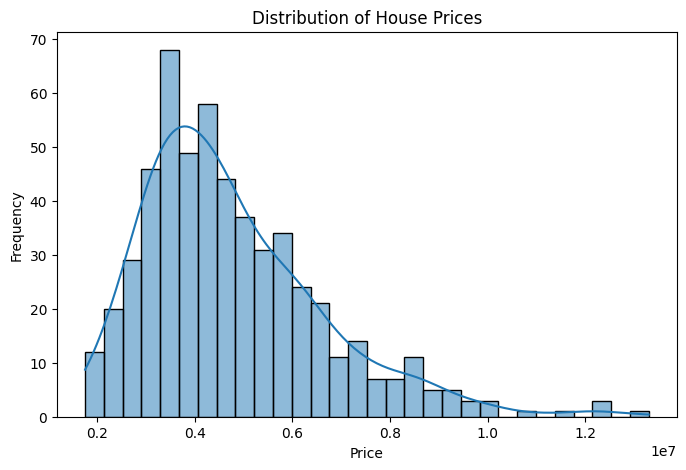

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

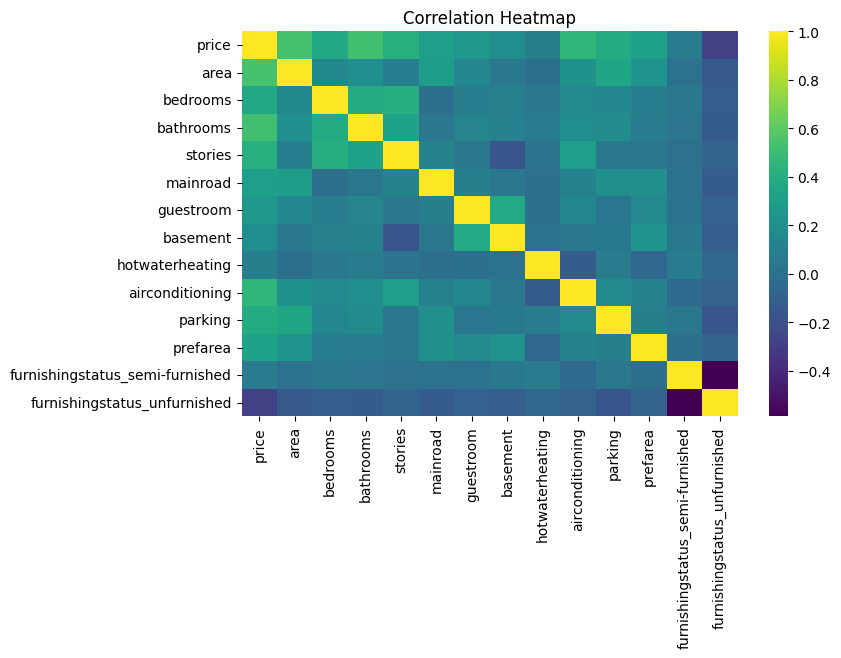

In [24]:
plt.figure(figsize=(8,5))

corr = df_encoded.corr()

sns.heatmap(
    corr,
    cmap='viridis',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

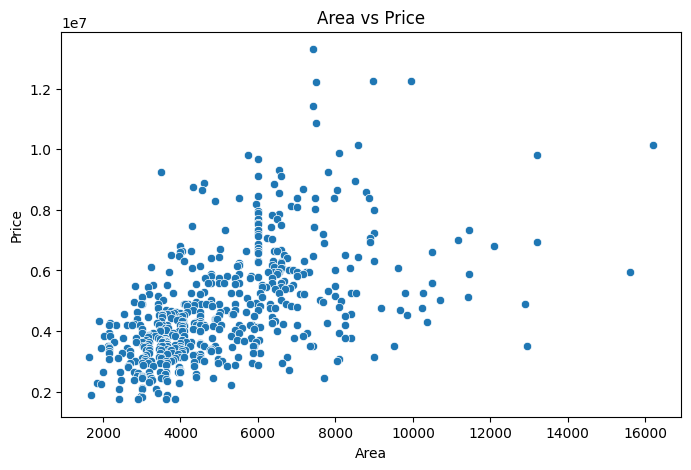

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['area'], y=df['price'])

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

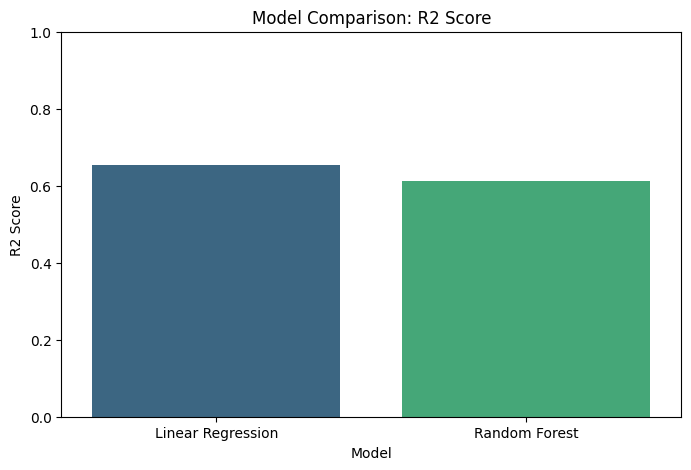

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(x='Model', y='R2 Score', data=comparison, hue='Model', palette='viridis', legend=False)

plt.title("Model Comparison: R2 Score")
plt.ylim(0, 1) # R2 score ranges up to 1
plt.ylabel("R2 Score")
plt.show()

Task 5: Insights & Summary

# Summary of Insights

1. **Top Price Drivers**: Both models highlight that **Area**, **Bathrooms**, and **Air Conditioning** are the most significant factors influencing house prices. In the Linear Regression model, having an extra bathroom adds the most value (~1.1M) relative to other features.
2. **Model Performance**:
    * **Linear Regression** achieved an **R2 Score of 0.65**.
    * **Random Forest** achieved an **R2 Score of 0.61**.
    * The Linear Regression model performed slightly better on this dataset, suggesting a relatively strong linear relationship between these specific features and price.
3. **Categorical Impact**:
    * Being **unfurnished** has a significant negative impact on price compared to being furnished.
    * Features like **preferred area** and **hot water heating** also provide substantial positive boosts to property value.
4. **Data Distribution**: The house prices are right-skewed, meaning most houses are concentrated in the lower price range (3M - 5M), with a few high-value outliers reaching up to 13M.
5. **Correlations**: The heatmap confirms a moderate positive correlation (0.54) between area and price, which is visually validated by the scatter plot.